# Assignment no 2

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
df = pd.read_csv("academic_performance.csv")
df.head()

,Student_ID,Maths,Science,English,Attendance
0,1,78.0,82.0,75.0,85.0
1,2,85.0,79.0,80.0,90.0
2,3,NaN,88.0,70.0,78.0
3,4,95.0,NaN,85.0,95.0
4,5,40.0,35.0,NaN,60.0


In [57]:
df.shape

(30, 5)

In [58]:
df.info

<bound method DataFrame.info of     Student_ID  Maths  Science  English  Attendance
0            1   78.0     82.0     75.0        85.0
1            2   85.0     79.0     80.0        90.0
2            3    NaN     88.0     70.0        78.0
3            4   95.0      NaN     85.0        95.0
4            5   40.0     35.0      NaN        60.0
5            6   88.0     90.0     88.0         NaN
6            7  150.0     85.0     65.0        88.0
7            8   72.0    400.0     78.0        92.0
8            9   66.0     70.0     68.0        75.0
9           10   55.0     60.0     58.0        65.0
10          11   90.0     92.0     94.0        98.0
11          12   48.0     52.0     50.0        55.0
12          13   82.0     78.0     80.0        82.0
13          14   76.0      NaN     74.0        80.0
14          15    NaN     65.0     60.0        70.0
15          16   68.0     72.0     70.0        77.0
16          17   85.0     88.0     90.0        89.0
17          18   92.0     95.0  

In [59]:
for cols in ['Maths','Science','English','Attendance']:
    print("inconsistant  values in ",cols)
    print(df[(df[cols]<0) | (df[cols]>100)])
    

inconsistant  values in  Maths
    Student_ID  Maths  Science  English  Attendance
6            7  150.0     85.0     65.0        88.0
20          21  110.0     85.0     88.0        90.0
inconsistant  values in  Science
   Student_ID  Maths  Science  English  Attendance
7           8   72.0    400.0     78.0        92.0
inconsistant  values in  English
Empty DataFrame
Columns: [Student_ID, Maths, Science, English, Attendance]
Index: []
inconsistant  values in  Attendance
    Student_ID  Maths  Science  English  Attendance
17          18   92.0     95.0     98.0       105.0


In [60]:
for cols in ['Maths','Science','English','Attendance']:
    df.loc[(df[cols]<0) | (df[cols]>100)]=np.nan

In [61]:
df

,Student_ID,Maths,Science,English,Attendance
0,1.0,78.0,82.0,75.0,85.0
1,2.0,85.0,79.0,80.0,90.0
2,3.0,NaN,88.0,70.0,78.0
3,4.0,95.0,NaN,85.0,95.0
4,5.0,40.0,35.0,NaN,60.0
5,6.0,88.0,90.0,88.0,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,9.0,66.0,70.0,68.0,75.0
9,10.0,55.0,60.0,58.0,65.0


In [62]:
df.isnull().sum()

Student_ID    4
Maths         6
Science       6
English       6
Attendance    6
dtype: int64

In [63]:
for cols in ['Maths','Science','English','Attendance']:
    df[cols]=df[cols].fillna(df[cols].mean())

In [64]:
df

,Student_ID,Maths,Science,English,Attendance
0,1.0,78.000,82.000000,75.000000,85.000000
1,2.0,85.000,79.000000,80.000000,90.000000
2,3.0,70.375,88.000000,70.000000,78.000000
3,4.0,95.000,70.208333,85.000000,95.000000
4,5.0,40.000,35.000000,71.083333,60.000000
5,6.0,88.000,90.000000,88.000000,76.166667
6,NaN,70.375,70.208333,71.083333,76.166667
7,NaN,70.375,70.208333,71.083333,76.166667
8,9.0,66.000,70.000000,68.000000,75.000000
9,10.0,55.000,60.000000,58.000000,65.000000


<Axes: >

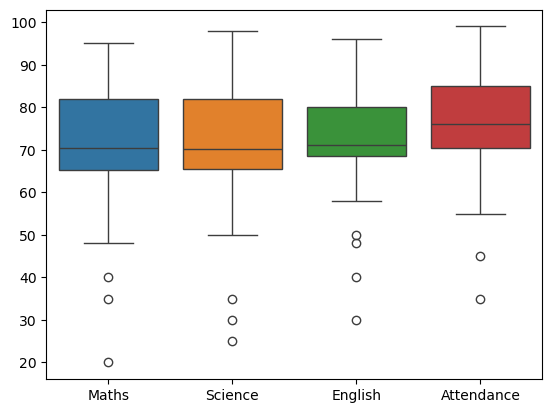

In [65]:
sns.boxplot(data=df[['Maths','Science','English','Attendance']])

In [66]:
cols=['Maths','Science','English','Attendance']
Q1=df[cols].quantile(0.25)
Q3=df[cols].quantile(0.75)
IQR=Q3-Q1
print(Q1)
print(Q3)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

Maths         65.25
Science       65.50
English       68.50
Attendance    70.50
Name: 0.25, dtype: float64
Maths         82.0
Science       82.0
English       80.0
Attendance    85.0
Name: 0.75, dtype: float64
Maths         40.125
Science       40.750
English       51.250
Attendance    48.750
dtype: float64
Maths         107.125
Science       106.750
English        97.250
Attendance    106.750
dtype: float64


In [67]:
for cols in ['Maths','Science','English','Attendance']:
    df.loc[(df[cols]<lower_bound[cols]),cols]=lower_bound[cols]
    

In [68]:
 for cols in ['Maths','Science','English','Attendance']:
    df.loc[(df[cols]>upper_bound[cols]),cols]=upper_bound[cols]

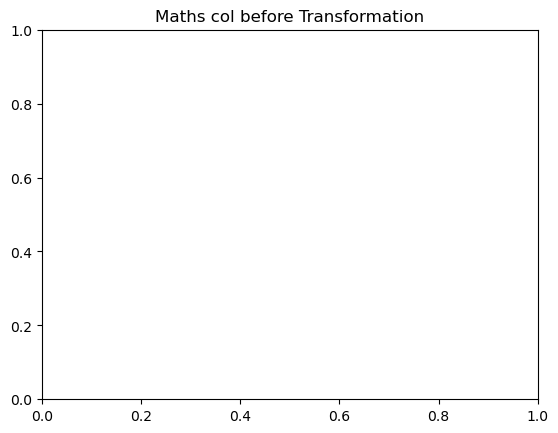

In [75]:
plt.title("Maths col before Transformation")
plt.show()

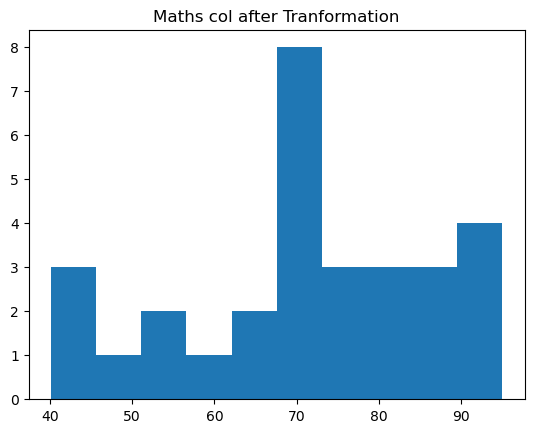

In [73]:
plt.hist(df['Maths'],bins=10)
plt.title("Maths col after Tranformation")
plt.show()

In [74]:
df['Maths'].skew()

np.float64(-0.5700820042315897)

In [84]:
max=df['Maths'].max()

In [85]:
df['Maths_reflected']=max+1-df['Maths']
df['Maths_transformed']=np.log(df['Maths_reflected'])

In [86]:
df['Maths_transformed'].skew()

np.float64(-1.7020690843090516)

In [87]:
df['Maths_transformed']=np.sqrt(df['Maths_reflected'])

In [88]:
df['Maths_transformed'].skew()

np.float64(-0.3260362565208521)

<Axes: xlabel='Maths_transformed', ylabel='Density'>

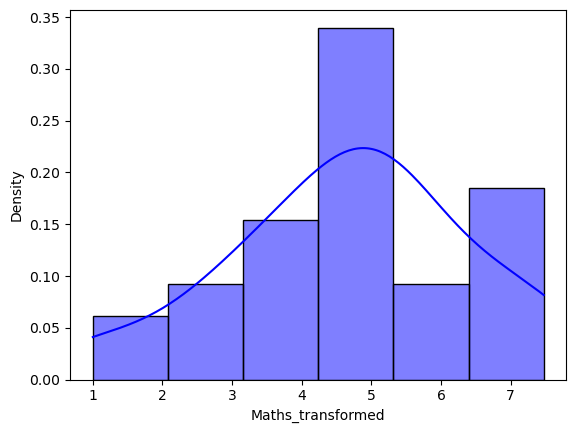

In [89]:
sns.histplot(df['Maths_transformed'],kde=True,color='blue',stat='density')